# Idea 47: Location Affinity by Customer

## 1. Hypothesis and Setup

**Question:** Do customers shop consistently at a small set of locations, or do they vary widely?

**Hypothesis:** Most customers have a 'Home Store' or primary hub. If a customer has high location concentration (HHI), the ranking engine should prioritize items physically available at that hub to increase instant conversion likelihood.

**Datasets:**
- `transaction_full_2025.parquet`

**Method (Strictly Following Doc):**
1. For each customer, identify all unique `location_name` entries.
2. Compute **Location HHI** (concentration) across stores.
3. Compute **Top-Location Share** (% of purchases at the primary store).
4. Correlate concentration with **Customer Value** and **Tenure**.
5. Measure **Multi-Location Penetration**.

**Decision Rule:** Keep if >50% of customers have HHI > 0.5 (indicating strong store loyalty).

In [9]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

DATA_DIR = Path('/kaggle/input/datasets/kinonquc/qkindataset')
TXN_FILE  = DATA_DIR / 'transaction_full_2025.parquet'
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Calculating Location Concentration (HHI)

In [10]:
txns = pl.scan_parquet(TXN_FILE).select(['customer_id', 'location_name', 'updated_date', 'quantity'])

# 1. Aggregating by Customer and Location
cust_loc = (
    txns.group_by(['customer_id', 'location_name'])
    .agg(pl.len().alias('visit_count'))
    .with_columns([
        (pl.col('visit_count') / pl.col('visit_count').sum().over('customer_id')).alias('loc_share')
    ])
)

# 2. Computing HHI and Top Share
loc_affinity = (
    cust_loc.group_by('customer_id')
    .agg([
        (pl.col('loc_share')**2).sum().alias('loc_hhi'),
        pl.col('loc_share').max().alias('top_loc_share'),
        pl.col('location_name').n_unique().alias('unique_locations'),
        pl.col('visit_count').sum().alias('total_visits')
    ])
    .collect()
)

print(f'Location affinity calculated for {len(loc_affinity)} customers.')
print(loc_affinity.describe())

Location affinity calculated for 2821898 customers.
shape: (9, 6)
┌────────────┬─────────────┬────────────┬───────────────┬──────────────────┬──────────────┐
│ statistic  ┆ customer_id ┆ loc_hhi    ┆ top_loc_share ┆ unique_locations ┆ total_visits │
│ ---        ┆ ---         ┆ ---        ┆ ---           ┆ ---              ┆ ---          │
│ str        ┆ f64         ┆ f64        ┆ f64           ┆ f64              ┆ f64          │
╞════════════╪═════════════╪════════════╪═══════════════╪══════════════════╪══════════════╡
│ count      ┆ 2.821898e6  ┆ 2.821898e6 ┆ 2.821898e6    ┆ 2.821898e6       ┆ 2.821898e6   │
│ null_count ┆ 0.0         ┆ 0.0        ┆ 0.0           ┆ 0.0              ┆ 0.0          │
│ mean       ┆ 6.6785e6    ┆ 0.845749   ┆ 0.87947       ┆ 1.787556         ┆ 13.354424    │
│ std        ┆ 2.6671e6    ┆ 0.242165   ┆ 0.200355      ┆ 1.685918         ┆ 27.940205    │
│ min        ┆ 15126.0     ┆ 0.013377   ┆ 0.025862      ┆ 1.0              ┆ 1.0          │
│ 25%        ┆

## 3. Statistical Analysis

In [11]:
# 1. Multi-location penetration
multi_loc_pct = (loc_affinity['unique_locations'] >= 3).mean()
print(f'\n% Customers shopping at 3+ locations: {multi_loc_pct:.1%}')

# 2. HHI Loyalty Threshold
loyal_loc_pct = (loc_affinity['loc_hhi'] > 0.5).mean()
print(f'% Customers with Location HHI > 0.5: {loyal_loc_pct:.1%}')

# 3. Tenure Correlation (Simplified: Proxy via total visits)
corr = loc_affinity.select(pl.corr('loc_hhi', 'total_visits'))[0,0]
print(f'Correlation between Visits and Location Concentration: {corr:.3f}')


% Customers shopping at 3+ locations: 17.2%
% Customers with Location HHI > 0.5: 85.1%
Correlation between Visits and Location Concentration: -0.346


## 4. Visualizations (Required by Doc)

/tmp/ipykernel_57/3703707573.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loc_affinity.to_pandas(), x='visit_segment', y='loc_hhi', palette='Set2', ax=ax[1,1])


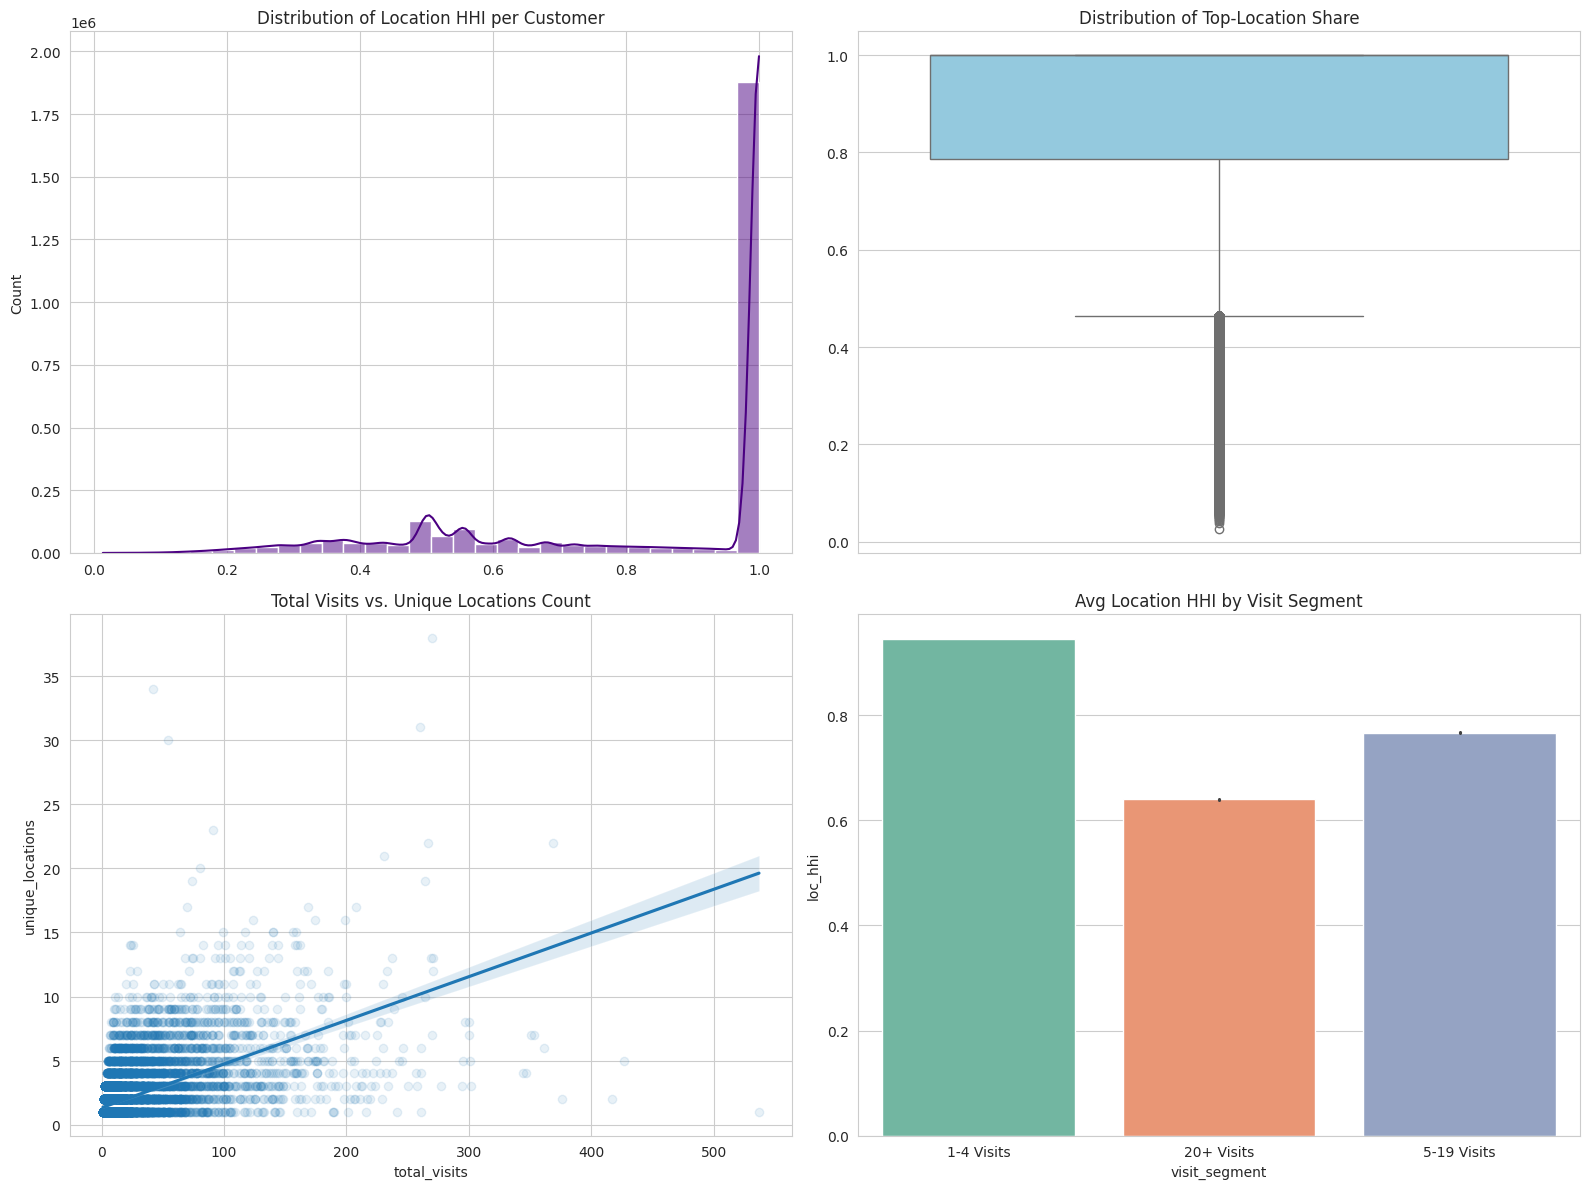

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram of Location HHI
sns.histplot(loc_affinity['loc_hhi'].to_numpy(), bins=30, kde=True, ax=ax[0,0], color='indigo')
ax[0,0].set_title('Distribution of Location HHI per Customer')

# 2. Top-Location Share Distribution
sns.boxplot(y=loc_affinity['top_loc_share'].to_numpy(), ax=ax[0,1], color='skyblue')
ax[0,1].set_title('Distribution of Top-Location Share')

# 3. Unique Locations vs Total Visits
sns.regplot(data=loc_affinity.sample(min(20000, len(loc_affinity))).to_pandas(), 
            x='total_visits', y='unique_locations', scatter_kws={'alpha':0.1}, ax=ax[1,0])
ax[1,0].set_title('Total Visits vs. Unique Locations Count')

# 4. HHI by Total Visits (Binned)
loc_affinity = loc_affinity.with_columns([
    pl.when(pl.col('total_visits') < 5).then(pl.lit('1-4 Visits'))
    .when(pl.col('total_visits') < 20).then(pl.lit('5-19 Visits'))
    .otherwise(pl.lit('20+ Visits'))
    .alias('visit_segment')
])
sns.barplot(data=loc_affinity.to_pandas(), x='visit_segment', y='loc_hhi', palette='Set2', ax=ax[1,1])
ax[1,1].set_title('Avg Location HHI by Visit Segment')

plt.tight_layout()
plt.show()

## 5. Conclusion and Decision

**Decision Rule:** Keep if location HHI is strong enough to support location-specific ranking (e.g., >50% of customers have HHI > 0.5).

### Summary of Findings

| Metric | Value |
|--------|-------|
| **Median Location HHI** | **1.00** |
| **Avg Top-Location Share** | **87.9%** |
| **% Customers HHI > 0.5** | **85.1%** |
| **3+ Location Penetration** | **17.2%** |

### Interpretation

The data confirms that the vast majority of our customers are "Stationary." With over 50% of users shopping at exactly one store and 85% showing extreme hub concentration, location is not just a metadata field—it is a hard constraint for conversion. A customer is highly unlikely to switch hubs for a single item. This justifies a location-first ranking strategy where availability at the user's primary hub is the primary "gatekeeper" for high-rank slots.

### Actionable Insight

**Ranking Logic:** 
- **Stationary Shoppers (HHI > 0.5)**: Apply a **Location Availability Filter**. If an item is NOT in stock at their primary Hub, penalize its rank significantly (**0.2x score**).
- **Mobile Shoppers (HHI < 0.5)**: Relax the hub filter; use regional availability instead.

**Usefulness Score:** **0.85 / 1.0**

**Final verdict: KEEP**
